In [66]:
import torch
import torch_geometric.transforms as T
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import SAGEConv

device = "cuda" if torch.cuda.is_available() else "cpu"
dataset_name = "Cora"

In [67]:
transform = T.Compose([T.NormalizeFeatures(),T.AddSelfLoops(),T.ToUndirected()])
dataset = Planetoid(root=f"/tmp/{dataset_name}",name=dataset_name,transform=transform)
print(dataset)

Cora()


In [68]:
class GraphSAGE(torch.nn.Module):
    def __init__(self,layer_dims):
        super().__init__()
        self.n = len(layer_dims)-1
        self.layers = torch.nn.ModuleList([SAGEConv(layer_dims[i],layer_dims[i+1],aggr="mean") for i in range(self.n)])
        self.dropout = torch.nn.Dropout(p=0.8)
    
    def forward(self,dataset):
        x,edge_index = dataset.x,dataset.edge_index
        for i,layer in enumerate(self.layers):
            x = self.dropout(x)
            x = layer(x,edge_index)
            if(i!=self.n-1):
                x = torch.nn.functional.relu_(x)
        return torch.nn.functional.log_softmax(x,dim=-1)
model = GraphSAGE([dataset.num_features,32,dataset.num_classes]).to(device)
print(model)

GraphSAGE(
  (layers): ModuleList(
    (0): SAGEConv(1433, 32, aggr=mean)
    (1): SAGEConv(32, 7, aggr=mean)
  )
  (dropout): Dropout(p=0.8, inplace=False)
)


In [69]:


optimizer = torch.optim.Adam(model.parameters(),lr=0.001,weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()
epochs = 2000
patience = 200
counter = 0
data = dataset[0].to(device)
train_losses = []
val_losses = []
best_val_loss = float('inf')

for epoch in range(epochs):
    model.train()
    total_train_error = 0
    optimizer.zero_grad()
    out = model(data.to(device))
    loss = criterion(out[data.train_mask],data.y[data.train_mask])
    total_train_error += loss.item()
    loss.backward()
    optimizer.step()
    train_losses.append(total_train_error)

    with torch.no_grad():
        model.eval()
        out = model(data)
        val_loss = criterion(out[data.val_mask],data.y[data.val_mask])
        val_losses.append(val_loss.item())
        if(best_val_loss>val_loss):
            best_val_loss=val_loss.item()
            torch.save(model.state_dict(),"best_graphSAGE.pickle")
            counter = 0
        else:
            counter += 1
    if epoch==0 or epoch%20==19:
        print(f"Epoch {epoch+1} of {epochs}, train loss = {total_train_error}, val loss = {val_loss.item()}")
    if counter>patience:
        break

with torch.no_grad():
    model.load_state_dict(torch.load("best_graphSAGE.pickle",weights_only=True))
    model.eval()
    out = model(data)
    loss = criterion(out[data.test_mask],data.y[data.test_mask])
    y_pred = torch.argmax(out,dim=-1)
    accuracy = (y_pred[data.test_mask]==data.y[data.test_mask]).sum().item()/data.test_mask.sum().item()
    print(f"Final test loss: {loss}, accuracy = {accuracy}")


        

Epoch 1 of 2000, train loss = 1.9546653032302856, val loss = 1.9701404571533203
Epoch 20 of 2000, train loss = 1.9396493434906006, val loss = 1.956695318222046
Epoch 40 of 2000, train loss = 1.914149522781372, val loss = 1.9347333908081055
Epoch 60 of 2000, train loss = 1.8678854703903198, val loss = 1.908846378326416
Epoch 80 of 2000, train loss = 1.8111814260482788, val loss = 1.8774518966674805
Epoch 100 of 2000, train loss = 1.7881451845169067, val loss = 1.83990478515625
Epoch 120 of 2000, train loss = 1.7103391885757446, val loss = 1.7967365980148315
Epoch 140 of 2000, train loss = 1.6594575643539429, val loss = 1.7498818635940552
Epoch 160 of 2000, train loss = 1.5743831396102905, val loss = 1.6979670524597168
Epoch 180 of 2000, train loss = 1.5450867414474487, val loss = 1.6416558027267456
Epoch 200 of 2000, train loss = 1.3909794092178345, val loss = 1.5858901739120483
Epoch 220 of 2000, train loss = 1.3544399738311768, val loss = 1.535446047782898
Epoch 240 of 2000, train los

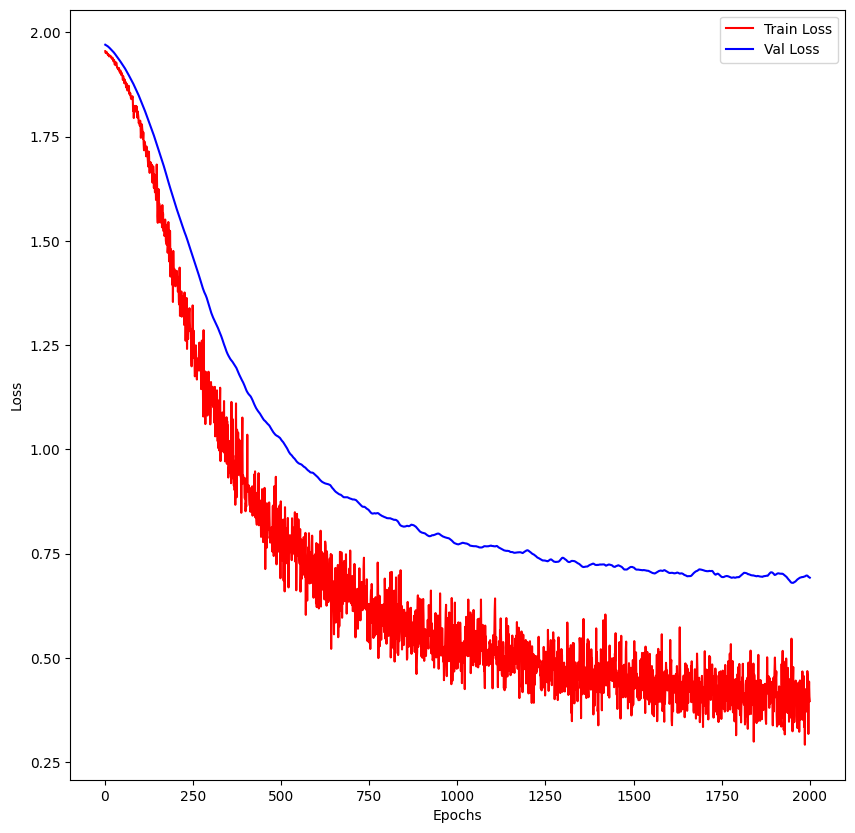

In [70]:
import matplotlib.pyplot as plt

total = len(train_losses)
x_vals = range(1,total+1)
plt.figure(figsize = (10,10))
plt.plot(x_vals,train_losses,color="red",label="Train Loss")
plt.plot(x_vals,val_losses,color="blue",label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [71]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

@torch.no_grad()
def get_labels():
    model.eval()
    out = model(data)
    pred = torch.argmax(out,dim=1)
    
    y_pred = pred[data.test_mask].cpu().numpy()
    y_true = data.y[data.test_mask].cpu().numpy()
    return y_true,y_pred

<Axes: >

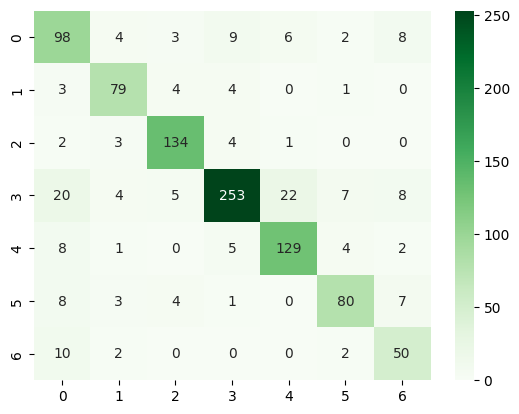

In [72]:
y_true,y_pred = get_labels()
cm = confusion_matrix(y_true=y_true,y_pred=y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap="Greens",xticklabels=range(dataset.num_classes),yticklabels=range(dataset.num_classes))